# DockingMT result export: retained optimization comparison

Owned by [#28](https://github.com/uibcdf/dockingmt/issues/28).
See the [measurement record](result_export.md) for methods and limits.

This **2026-10-02 baseline** compares dictionary export before and after removing
redundant copies. Five deterministic synthetic cases exercise coordinate volume,
pose count and existing atom-map metadata. An existing exploratory 181L result
manifest is also measured. Every serialized record has the same SHA-256 before
and after; independent snapshot ownership is tested separately.

The notebook reads the two versioned raw reports and renders tables/figures.
It does not execute a benchmark or import DockingMT, MolSysMT or a native engine.
Running it requires Jupyter/IPython and Matplotlib, plus this checkout for the
existing comparison helper. These are not package runtime dependencies.

In [1]:
import json
import sys
from pathlib import Path

from IPython.display import Markdown, display

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents)
             if (path / 'devtools/benchmark_result_export.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from within the DockingMT checkout.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from devtools.benchmark_result_export import _compare

DATA = ROOT / 'devguide/validation/data/result_export'
before = json.loads((DATA / 'before_2026-10-02.json').read_text())
after = json.loads((DATA / 'after_2026-10-02.json').read_text())
comparison = _compare(after, before)
assert all(case['records_match'] for case in comparison.values())
cases = ['small_mapped', 'many_small', 'large_coordinates',
         'many_poses', 'large_mapped', 'manifest']
print(f'Verified {len(comparison)} matching JSON snapshots and comparable measurement settings.')
print('Scientific modules loaded by report analysis:',
      {name: name in sys.modules for name in ('dockingmt', 'molsysmt', 'vina', 'molsysviewer')})

Verified 6 matching JSON snapshots and comparable measurement settings.
Scientific modules loaded by report analysis: {'dockingmt': False, 'molsysmt': False, 'vina': False, 'molsysviewer': False}


## Method and source identity

Three independent dictionary exports per case, timed with `perf_counter`.
Imports, fixture construction, collection between samples, hashing and snapshot
disposal are excluded. `tracemalloc` and `cProfile` use **separate calls**;
their instrumented times do not enter the timing medians. Memory means peak
traced Python allocations during one export, not process RSS or total RAM.
Before and after run sequentially on the same local environment. No portable
runtime budget, campaign capacity or scientific accuracy claim is made.

In [2]:
print(json.dumps(before['environment'], indent=2))
for label, report in (('Before', before), ('After', after)):
    print(label, json.dumps({field: report[field] for field in
                            ('source_revision', 'benchmark_sha256')}, indent=2))

{
  "platform": "Linux-7.0.0-28-generic-x86_64-with-glibc2.39",
  "python": "3.13.14",
  "versions": {
    "argdigest": "0.12.1+7.ga2edfe9",
    "depdigest": "0.10.1+15.g78a9106",
    "numpy": "2.4.6",
    "pyunitwizard": "0.27.0",
    "smonitor": "0.18.0+1.gb308ee0"
  }
}
Before {
  "source_revision": {
    "code_sha256": "5db4db57cb25294c5e2865fbced654adcfbdbcc59aad5b3a51050abb7816597c",
    "git_head": "6d1a0669582cefbe58af201719d02c4bee8f08a8",
    "worktree_dirty": true
  },
  "benchmark_sha256": "da865e2bf2229c13726f87e93c5a6d65c3355a86aaba97cf88263b3209a08e05"
}
After {
  "source_revision": {
    "code_sha256": "d9168cb5adcf243a408f59b81c2b3a20291670fd1750298c6d53d2d4b12a05a2",
    "git_head": "6d1a0669582cefbe58af201719d02c4bee8f08a8",
    "worktree_dirty": true
  },
  "benchmark_sha256": "e7e5efb09f20e697a182c3de7b83f0883d308f33ec434394f8bba00b4eecad46"
}


In [3]:
def show_table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |',
             '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(map(str, row)) + ' |' for row in rows)
    display(Markdown('\n'.join(lines)))

show_table(
    ['Case', 'Poses', 'Atoms/pose', 'Before (s)', 'After (s)',
     'Before/after ratio', 'Before peak (MiB)', 'After peak (MiB)'],
    [[name, before['cases'][name]['n_poses'],
      sorted(set(before['cases'][name]['atoms_per_pose'])),
      f"{before['cases'][name]['median_seconds']:.6f}",
      f"{after['cases'][name]['median_seconds']:.6f}",
      f"{1 / comparison[name]['median_ratio']:.2f}",
      f"{before['cases'][name]['python_peak_bytes'] / 1024**2:.2f}",
      f"{after['cases'][name]['python_peak_bytes'] / 1024**2:.2f}"]
     for name in cases],
)

| Case | Poses | Atoms/pose | Before (s) | After (s) | Before/after ratio | Before peak (MiB) | After peak (MiB) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| small_mapped | 9 | [64] | 0.009387 | 0.003560 | 2.64 | 0.48 | 0.22 |
| many_small | 256 | [32] | 0.067674 | 0.017690 | 3.83 | 3.35 | 1.56 |
| large_coordinates | 256 | [1024] | 1.453565 | 0.085978 | 16.91 | 87.19 | 40.32 |
| many_poses | 1024 | [32] | 0.241427 | 0.065561 | 3.68 | 13.53 | 6.22 |
| large_mapped | 256 | [1024] | 4.422038 | 1.183333 | 3.74 | 208.16 | 90.66 |
| manifest | 4 | [6] | 0.002031 | 0.001397 | 1.45 | 0.07 | 0.05 |

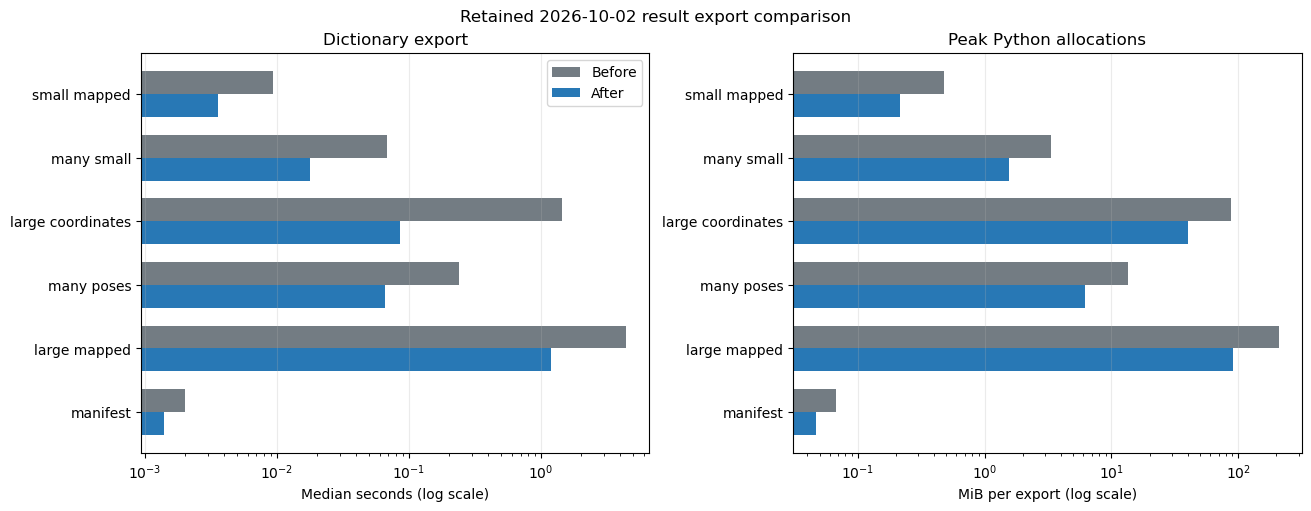

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')
for index, (label, report) in enumerate((('Before', before), ('After', after))):
    positions = [position + (index - 0.5) * 0.36 for position in range(len(cases))]
    axes[0].barh(positions, [report['cases'][name]['median_seconds'] for name in cases],
                 height=0.36, label=label, color=('#737c83', '#2878b5')[index])
    axes[1].barh(positions, [report['cases'][name]['python_peak_bytes'] / 1024**2
                            for name in cases], height=0.36,
                 label=label, color=('#737c83', '#2878b5')[index])
for ax, title, unit in zip(axes, ('Dictionary export', 'Peak Python allocations'),
                          ('Median seconds (log scale)', 'MiB per export (log scale)')):
    ax.set_yticks(range(len(cases)), [name.replace('_', ' ') for name in cases])
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_xlabel(unit)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)
axes[0].legend()
fig.suptitle('Retained 2026-10-02 result export comparison')
plt.show()

## Raw timing samples and profile evidence

The original timings remain available below. Profile cumulative times overlap;
compare call counts and attribution, not their instrumented seconds to the
uninstrumented median. No timing threshold is enforced by tests.

In [5]:
show_table(['Case', 'Before samples (s)', 'After samples (s)'],
           [[name, ', '.join(f'{value:.6f}' for value in before['cases'][name]['seconds']),
             ', '.join(f'{value:.6f}' for value in after['cases'][name]['seconds'])]
            for name in cases])
for name in ('large_coordinates', 'large_mapped'):
    for label, report in (('Before', before), ('After', after)):
        display(Markdown(f'### {name} — {label}'))
        show_table(['Function', 'Total calls', 'Cumulative profiled seconds'],
                   [[entry['function'], entry['total_calls'], f"{entry['cumulative_seconds']:.6f}"]
                    for entry in report['cases'][name]['profile_top_cumulative'][:5]])

| Case | Before samples (s) | After samples (s) |
| --- | --- | --- |
| small_mapped | 0.009047, 0.010777, 0.009387 | 0.003588, 0.003560, 0.003168 |
| many_small | 0.067674, 0.069603, 0.060162 | 0.018759, 0.016972, 0.017690 |
| large_coordinates | 1.453565, 1.407663, 1.470099 | 0.085978, 0.091691, 0.081505 |
| many_poses | 0.241427, 0.241322, 0.249419 | 0.065499, 0.066286, 0.065561 |
| large_mapped | 4.171936, 4.422038, 4.485570 | 1.183333, 1.181237, 1.197500 |
| manifest | 0.002067, 0.002031, 0.002027 | 0.001481, 0.001348, 0.001397 |

### large_coordinates — Before

| Function | Total calls | Cumulative profiled seconds |
| --- | --- | --- |
| results.py:564:to_dict | 1 | 7.254721 |
| copy.py:119:deepcopy | 2119231 | 7.140498 |
| copy.py:218:_deepcopy_dict | 2571 | 7.139318 |
| copy.py:192:_deepcopy_list | 525827 | 7.108028 |
| results.py:208:to_dict | 256 | 3.647964 |

### large_coordinates — After

| Function | Total calls | Cumulative profiled seconds |
| --- | --- | --- |
| results.py:566:to_dict | 1 | 0.135726 |
| results.py:208:to_dict | 256 | 0.132437 |
| ~:0:<method 'tolist' of 'numpy.ndarray' objects> | 256 | 0.037212 |
| copy.py:119:deepcopy | 10045 | 0.027600 |
| copy.py:218:_deepcopy_dict | 1035 | 0.026647 |

### large_mapped — Before

| Function | Total calls | Cumulative profiled seconds |
| --- | --- | --- |
| results.py:564:to_dict | 1 | 28.220243 |
| copy.py:119:deepcopy | 8415807 | 28.052453 |
| copy.py:218:_deepcopy_dict | 526859 | 28.051010 |
| copy.py:192:_deepcopy_list | 526851 | 28.004588 |
| results.py:208:to_dict | 256 | 14.678196 |

### large_mapped — After

| Function | Total calls | Cumulative profiled seconds |
| --- | --- | --- |
| results.py:566:to_dict | 1 | 7.170733 |
| results.py:208:to_dict | 256 | 7.167413 |
| copy.py:119:deepcopy | 3158333 | 7.023497 |
| copy.py:218:_deepcopy_dict | 263179 | 7.022541 |
| copy.py:192:_deepcopy_list | 1026 | 6.994830 |

## Interpretation

The coordinate-heavy case falls from ~1.45 s to ~0.086 s; the case with full
atom maps falls from ~4.42 s to ~1.18 s. Peak traced allocations fall from
~87.2 to ~40.3 MiB and ~208.2 to ~90.7 MiB respectively. The real small 181L
manifest changes from ~2.03 to ~1.40 ms; that small difference is sensitive to
timing noise. The strong improvement is in large dictionary snapshots.

Each pose still copies its structured metadata, scores and identifiers, while
its newly allocated coordinate lists already own their data. Result context is
copied once, and independently owned base pose snapshots are retained. Custom
serializers still receive a defensive copy when ownership is unknown. This keeps
the schema and scientific content unchanged. Reconstruction has not changed.
The mapped case still spends most time copying required metadata; this does
not justify weakening isolation, sharing mutable records or adding caches.

These ratios concern **dictionary export only**. They do not imply faster
Vina search, map construction, preparation, JSON encoding or file writing.

## Reproduce on a chosen revision

From the checkout root, use the existing tool:

```bash
python -m devtools.benchmark_result_export --report /tmp/export.json --memory --profile
```

Repeat on the reference and candidate revisions with the same environment,
case selection and repeat count, then pass `--reference /tmp/export-reference.json`.
`--case small_mapped` selects a quick case; `--manifest PATH` adds an existing
DockingResult record. To reproduce the optional real case, generate an 181L
manifest with `devtools/redocking_181l.py record`; keep its bytes fixed across
both export runs. The retained manifest digest identifies the historical input;
a newly generated manifest will carry its own provenance and digest.

New reports should retain their own date and source/environment identity.
Keep these historical files unchanged when collecting later measurements.